In [12]:
import pandas as pd
import numpy as np 
from sklearn.datasets import make_classification
import random

In [2]:
x,y=make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [6]:
df=pd.DataFrame(x,columns=['col1','col2','col3','col4','col5'])
df['target']=y

In [7]:
df.shape
df.head()

,col1,col2,col3,col4,col5,target
0,-0.076251,4.290003,2.838650,-0.695589,1.716936,0
1,-1.189092,1.505655,2.193878,0.269440,0.004471,0
2,1.725490,-3.083228,-3.155401,2.918281,-0.849247,1
3,-2.839182,-0.780598,-0.827878,-0.214249,-2.033162,0
4,-0.834655,-0.856588,0.636226,1.703084,0.601931,1


In [37]:
# Row sampling function
def row_sample(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [38]:
# Col sampling function
def feature_sample(df,percent):
    col=random.sample(df.columns.to_list()[:-1],int(percent*(df.shape[1]-1)))
    new_df=df[col]
    new_df['target']=df['target']
    return new_df

In [40]:
# combin row and feature
def row_feature_sample(df,row_percent,feature_percent):
    new_df=row_sample(df,row_percent)
    return feature_sample(new_df,feature_percent)

In [44]:
row_feature_sample(df,0.5,0.5)

,col1,col3,target
69,-0.435511,-0.574931,0
45,-1.134182,-1.436849,0
75,-0.935424,1.777017,0
39,0.167814,0.054068,1
30,1.681118,-0.603466,1
96,-2.016378,2.346380,0
49,0.368205,-3.086771,1
42,-1.290116,1.245774,0
55,0.594414,1.369524,1
94,1.788389,-4.526263,1


In [45]:
# Make different dataframe
df1=row_sample(df,0.2)
df2=row_sample(df,0.2)
df3=row_sample(df,0.2)

In [46]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [49]:
clf1.fit(df1.iloc[:,0:-1],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
#plot the tree
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[0] <= -0.426\ngini = 0.495\nsamples = 20\nvalue = [9, 11]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.625, 0.5, '  False')]

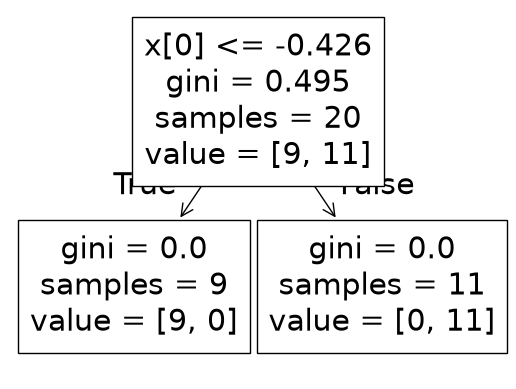

In [51]:
plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[0] <= 0.188\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= 1.898\ngini = 0.278\nsamples = 12\nvalue = [2, 10]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]')]

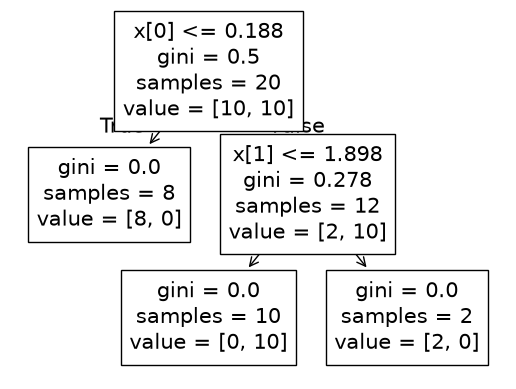

In [52]:
plot_tree(clf2)

[Text(0.4, 0.8333333333333334, 'x[0] <= 0.103\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= 1.877\ngini = 0.165\nsamples = 11\nvalue = [1, 10]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]')]

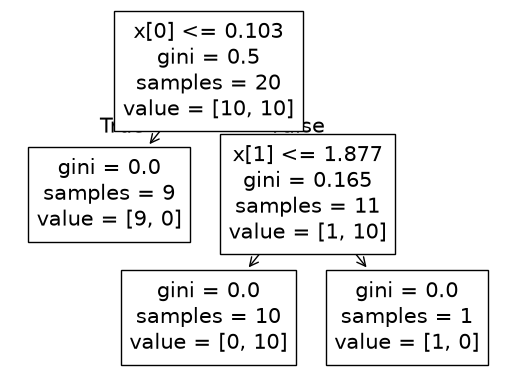

In [53]:
plot_tree(clf3)

In [54]:
df.head(1)

,col1,col2,col3,col4,col5,target
0,-0.076251,4.290003,2.83865,-0.695589,1.716936,0


In [56]:
# prediction from the each DT
clf1.predict(np.array([-0.076251,4.290003,2.83865,-0.695589,1.716936]).reshape(1,5))

c:\Users\Mubashar Ali\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [57]:
clf2.predict(np.array([-0.076251,4.290003,2.83865,-0.695589,1.716936]).reshape(1,5))

c:\Users\Mubashar Ali\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [58]:
clf3.predict(np.array([-0.076251,4.290003,2.83865,-0.695589,1.716936]).reshape(1,5))

c:\Users\Mubashar Ali\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [66]:
# Try col_sampling base
col_df1=feature_sample(df,0.5)
col_df2=feature_sample(df,0.5)
col_df3=feature_sample(df,0.5)

In [67]:
col_df1.shape

(100, 3)

In [75]:
from sklearn.model_selection import train_test_split
x_train1,x_test1,y_train1,y_test1=train_test_split(col_df1.iloc[:,0:2],col_df1.iloc[:,-1],test_size=0.2,random_state=2)

In [76]:
x_train2,x_test2,y_train2,y_test2=train_test_split(col_df2.iloc[:,0:2],col_df2.iloc[:,-1],test_size=0.2,random_state=2)

In [77]:
x_train3,x_test3,y_train3,y_test3=train_test_split(col_df3.iloc[:,0:2],col_df3.iloc[:,-1],test_size=0.2,random_state=2)

In [79]:
col_clf1=DecisionTreeClassifier()
col_clf2=DecisionTreeClassifier()
col_clf3=DecisionTreeClassifier()

In [81]:
col_clf1.fit(x_train1,y_train1)
col_clf2.fit(x_train2,y_train2)
col_clf3.fit(x_train3,y_train3)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [83]:
x_test1.iloc[0,:]

col4    1.498874
col3    0.284998
Name: 83, dtype: float64

In [102]:
col_clf1.predict(x_test1.iloc[0:1,:])

array([1])

In [101]:
col_clf2.predict(x_test2.iloc[0:1,:])

array([0])

In [103]:
col_clf3.predict(x_test3.iloc[0:1,:])

array([0])

In [113]:
y_test3.iloc[0]

np.int64(0)